# Deep Q-Network (DQN) for Reinforcement Learning

This notebook demonstrates the implementation of a DQN agent to solve an environment from the Gymnasium library, following the required exposure structure.

## A. Definición del Entorno del Modelo

En esta sección, definiremos los componentes fundamentales del aprendizaje por refuerzo para nuestro agente DQN:

*   **Espacio de Estados:** Representación del entorno (ej. posiciones, velocidades o píxeles).
*   **Espacio de Acciones:** Acciones discretas que el agente puede tomar.
*   **Función de Recompensa:** Incentivos numéricos para guiar el aprendizaje.
*   **Naturaleza del Algoritmo:** DQN es un algoritmo **Off-Policy** y **Basado en Valor**, ya que utiliza una red neuronal para aproximar la función de valor Q y aprende de una memoria de experiencias pasadas.

In [ ]:
# Instalación de dependencias necesarias
!pip install gymnasium[classic_control] torch matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.5 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# Configuración del entorno
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print(f"Espacio de Estados: {state_size}")
print(f"Espacio de Acciones: {action_size}")

Espacio de Estados: 4
Espacio de Acciones: 2


## B. El Dilema de Exploración vs. Explotación

En DQN, este equilibrio se gestiona mediante una estrategia **Epsilon-Greedy**:

*   **Exploración:** Con una probabilidad $\epsilon$, el agente elige una acción al azar para descubrir nuevas recompensas.
*   **Explotación:** Con una probabilidad $1-\epsilon$, el agente elige la acción con el valor Q más alto predicho por la red.
*   **Decaimiento:** El valor de $\epsilon$ disminuye gradualmente a medida que el agente aprende, pasando de probarlo todo a confiar en su conocimiento.

## C. Simulación Práctica

Implementaremos la red neuronal (Q-Network) y la memoria de experiencias (Replay Buffer).

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done

    def __len__(self):
        return len(self.buffer)

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = ReplayBuffer(10000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = QNetwork(state_size, action_size).to(self.device)
        self.target_model = QNetwork(state_size, action_size).to(self.device)
        self.update_target_network()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

    def update_target_network(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            act_values = self.model(state)
        return torch.argmax(act_values).item()

    def train(self, batch_size):
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.target_model(next_states).max(1)[0]
        target_q = rewards + (self.gamma * next_q * (1 - dones))

        loss = nn.MSELoss()(current_q, target_q.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

## D. Análisis de Convergencia

Ejecutaremos el entrenamiento y graficaremos la recompensa acumulada para verificar el aprendizaje del agente.

Episodio: 10/150, Recompensa: 24.0, Epsilon: 0.54
Episodio: 20/150, Recompensa: 26.0, Epsilon: 0.24
Episodio: 30/150, Recompensa: 112.0, Epsilon: 0.01
Episodio: 40/150, Recompensa: 177.0, Epsilon: 0.01
Episodio: 50/150, Recompensa: 122.0, Epsilon: 0.01
Episodio: 60/150, Recompensa: 321.0, Epsilon: 0.01
Episodio: 70/150, Recompensa: 149.0, Epsilon: 0.01
Episodio: 80/150, Recompensa: 119.0, Epsilon: 0.01
Episodio: 90/150, Recompensa: 146.0, Epsilon: 0.01
Episodio: 100/150, Recompensa: 148.0, Epsilon: 0.01
Episodio: 110/150, Recompensa: 199.0, Epsilon: 0.01
Episodio: 120/150, Recompensa: 213.0, Epsilon: 0.01
Episodio: 130/150, Recompensa: 212.0, Epsilon: 0.01
Episodio: 140/150, Recompensa: 500.0, Epsilon: 0.01
Episodio: 150/150, Recompensa: 500.0, Epsilon: 0.01


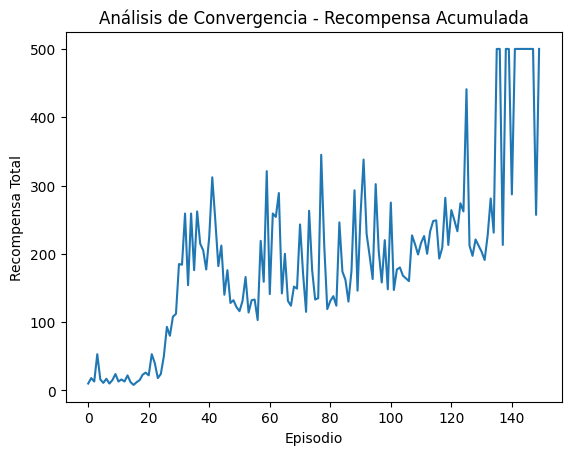

In [ ]:
agent = DQNAgent(state_size, action_size)
episodes = 150
batch_size = 64
rewards_history = []

for e in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        agent.train(batch_size)

    agent.update_target_network()
    rewards_history.append(total_reward)
    if (e + 1) % 10 == 0:
        print(f"Episodio: {e+1}/{episodes}, Recompensa: {total_reward}, Epsilon: {agent.epsilon:.2f}")

plt.plot(rewards_history)
plt.title("Análisis de Convergencia - Recompensa Acumulada")
plt.xlabel("Episodio")
plt.ylabel("Recompensa Total")
plt.show()

## E. Preparación para Despliegue (GitHub & Streamlit)

Para subir tu proyecto a un repositorio y desplegarlo en Streamlit, necesitas un archivo `requirements.txt`. El siguiente código lo generará automáticamente basándose en las librerías que hemos usado.

In [ ]:
requirements = """
gymnasium
pygame-ce
torch
numpy
matplotlib
streamlit
setuptools
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("Archivo requirements.txt optimizado para la nube.")

Archivo requirements.txt optimizado para la nube.


### Estructura sugerida para tu repositorio:

1. `app.py`: El script principal de Streamlit.
2. `model.py`: Contiene las clases `QNetwork` y `DQNAgent`.
3. `requirements.txt`: El archivo generado arriba.
4. `dqn_model.pth`: (Opcional) El estado de la red entrenada guardado con `torch.save`.

Aquí tienes cómo guardar el modelo entrenado para no tener que re-entrenarlo en Streamlit:

In [ ]:
torch.save(agent.model.state_dict(), 'dqn_cartpole_model.pth')
print("Modelo guardado como dqn_cartpole_model.pth")

Modelo guardado como dqn_cartpole_model.pth


### F. Generación del Script para Streamlit (`app.py`)

Este código crea el archivo principal que leerá Streamlit para mostrar los resultados en la web.

In [ ]:
app_script = """
import streamlit as st
import gymnasium as gym
import torch
import torch.nn as nn
import numpy as np
import time

# Definición de la Red
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

st.set_page_config(page_title="DQN CartPole Demo", layout="centered")
st.title("DQN Agent - CartPole Demo")
st.write("Este agente fue entrenado usando Deep Q-Learning.")

# Cargar modelo
env = gym.make('CartPole-v1', render_mode='rgb_array')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

model = QNetwork(state_size, action_size)
try:
    model.load_state_dict(torch.load('dqn_cartpole_model.pth', map_location=torch.device('cpu')))
    st.success("Modelo cargado correctamente!")
except:
    st.error("No se encontró el archivo dqn_cartpole_model.pth")

if st.button('Ejecutar Episodio'):
    state, _ = env.reset()
    # Usamos st.empty con una clave para mayor estabilidad
    placeholder = st.empty()
    total_reward = 0
    done = False

    while not done:
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action = torch.argmax(model(state_t)).item()

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # Renderizado estable
        frame = env.render()
        placeholder.image(frame, channels="RGB", use_container_width=True)
        time.sleep(0.05) # Aumentamos ligeramente el delay para estabilidad

    st.write(f"Recompensa final: {total_reward}")
"""

with open('app.py', 'w') as f:
    f.write(app_script.strip())

print("Archivo app.py actualizado con corrección de estabilidad DOM.")

Archivo app.py actualizado con corrección de estabilidad DOM.


### G. Archivo de Configuración de Streamlit
Creamos una carpeta `.streamlit` y un archivo `config.toml` para optimizar el rendimiento en la nube.

In [ ]:
!mkdir -p .streamlit

config_toml = """
[server]
headless = true
enableCORS = false
enableXsrfProtection = false
"""

with open('.streamlit/config.toml', 'w') as f:
    f.write(config_toml.strip())

print("Configuración de Streamlit creada.")

Configuración de Streamlit creada.


### H. Descarga de Archivos para GitHub
Ejecuta esta celda para descargar todo lo necesario en un archivo ZIP listo para subir a tu repositorio.

In [ ]:
import shutil
from google.colab import files

# Lista de archivos a incluir
files_to_zip = ['app.py', 'requirements.txt', 'dqn_cartpole_model.pth']

# Limpiar y preparar
!rm -rf deploy_package
!mkdir -p deploy_package

for f in files_to_zip:
    shutil.copy(f, 'deploy_package/')

# Generar el zip final corregido
shutil.make_archive('proyecto_dqn_final_v2', 'zip', 'deploy_package')

# Descargar
files.download('proyecto_dqn_final_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>